In [1]:
import sys
sys.path.append("C:/Users/siddh/Desktop/Graduate files/Research/mpemba_functions/")

import mpemba
import fokker_planck

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('default')

100%|██████████| 9999/9999 [00:05<00:00, 1674.32it/s]


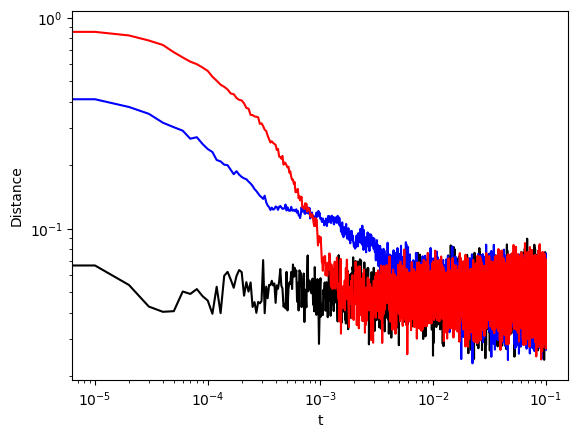

In [2]:
srushtian_potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.6, force_asymmetry=0.3, x_min=-5, x_max=5)
srushtian_ensemble = mpemba.construct_simulated_ensemble(srushtian_potential, k_BTs=[11.95,3.05,1], num_particles=5_000, clip_force=50)
srushtian_ensemble.plot_distances()


In [19]:
srushtian_ensemble.export_distances("srushtianDistances_5000.csv")

Initial histogram, T = 11.95: chi^2 = 0.1925529457405296
Final histogram, T = 11.95: chi^2 = 0.09440444528164725
Initial histogram, T = 3.05: chi^2 = 0.1912082753528813
Final histogram, T = 3.05: chi^2 = 0.1692357923140942
Initial histogram, T = 1.0: chi^2 = 0.13338199680767882
Final histogram, T = 1.0: chi^2 = 0.17804105249054872


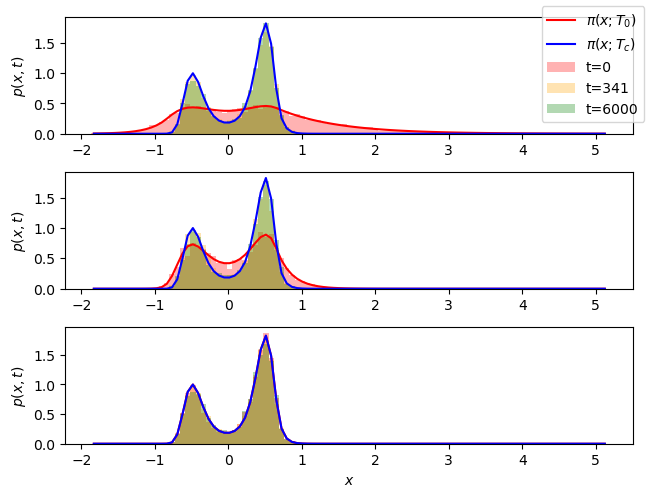

In [15]:
_ = srushtian_ensemble.gut_checks()

In [52]:
p_trajectories = fokker_planck.analytic_solution([12.053, 3.05], srushtian_potential, t_max=0.03, D=150, n_x=1000, dt=1e-7, error_tolerance=4e-3)

100%|██████████| 2/2 [00:14<00:00,  7.15s/it]


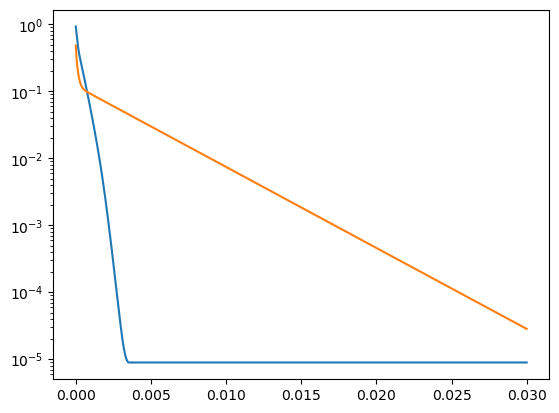

In [54]:
distances = fokker_planck.analytical_distances_to_boltzmann(p_trajectories, srushtian_potential)

times = np.arange(p_trajectories.shape[2])*1e-5
plt.semilogy(times, distances.T)
df = pd.DataFrame(distances.T, columns=['h','w'], index=times)
df.to_csv("srushtianDistances_FPE.csv")

In [3]:
quench = mpemba.quench_methods.ExponentialQuench(None, tau=1/np.abs(srushtian_potential.eigs_k(D=150, k=3)[0]))

p_quench = fokker_planck.analytic_solution([12,3], srushtian_potential, t_max=0.01, D=150, n_x=500, dt=1e-6, error_tolerance=4e-3, quench_protocol=quench)

  0%|          | 0/2 [00:00<?, ?it/s]


ValueError: ('Probability conservation failed! Z=', nan, 't=', 0)

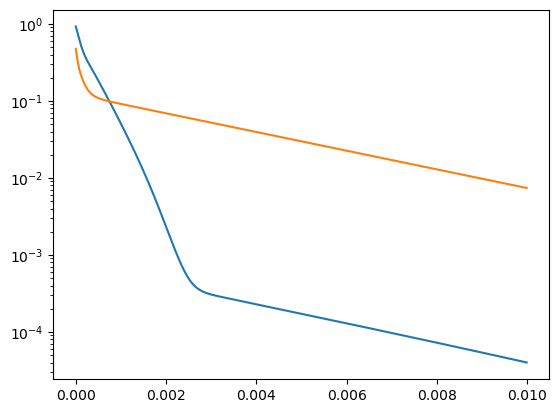

In [25]:
distances = fokker_planck.analytical_distances_to_boltzmann(p_quench, srushtian_potential)

times = np.arange(p_trajectories.shape[2])*1e-5
plt.semilogy(times, distances.T)
df = pd.DataFrame(distances.T, columns=['h','w'], index=times)
df.to_csv("srushtianDistances_FPE_lambda3.csv")